In [9]:
import os
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
from transformers import SegformerForSemanticSegmentation

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using compute device: {device}")

BASE_DIR = "../01_data/model_ready_production"

# ONLY Resize and Normalize. NO Random Augmentations!
static_transform = A.Compose([
    A.Resize(1024, 1024), 
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), 
    ToTensorV2() 
])

class OverfitDataset(Dataset):
    def __init__(self, split, transform=None, max_images=10):
        self.img_dir = os.path.join(BASE_DIR, split, "images")
        self.mask_dir = os.path.join(BASE_DIR, split, "masks")
        self.transform = transform
        
        all_images = sorted(os.listdir(self.img_dir))
        
        # Set a seed so we pull the EXACT SAME 10 random images every epoch
        random.seed(42) 
        self.images = random.sample(all_images, min(max_images, len(all_images)))
        
    def __len__(self):
        return len(self.images)
        
    def __getitem__(self, idx):
        img_name = self.images[idx]
        with rasterio.open(os.path.join(self.img_dir, img_name)) as src_img:
            image = np.transpose(src_img.read(), (1, 2, 0)) 
        with rasterio.open(os.path.join(self.mask_dir, img_name)) as src_mask:
            mask = src_mask.read(1)
            
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image, mask = augmented['image'], augmented['mask']
            
        return image, mask.to(torch.long)

# Load 10 random images
tiny_dataset = OverfitDataset('train', transform=static_transform, max_images=10)
tiny_loader = DataLoader(tiny_dataset, batch_size=4, shuffle=False)

print(f"Loaded {len(tiny_dataset)} random images for the Overfit Test.")

Using compute device: mps
Loaded 10 random images for the Overfit Test.


In [10]:
model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b0", num_labels=8, ignore_mismatched_sizes=True
).to(device)

loss_fn = nn.CrossEntropyLoss(ignore_index=255)
optimizer = optim.AdamW(model.parameters(), lr=0.0005)

epochs = 100
print("🚀 Starting Overfit Test (100 Epochs on 10 Random Images)...")

for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
    
    # Loop through the 3 batches (4 + 4 + 2 images = 10 total)
    for images, masks in tiny_loader:
        images, masks = images.to(device), masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(pixel_values=images)
        upsampled_logits = F.interpolate(outputs.logits, size=masks.shape[-2:], mode="bilinear", align_corners=False)
        
        loss = loss_fn(upsampled_logits, masks)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/100 | Avg Loss: {epoch_loss / len(tiny_loader):.4f}")

print("✅ Overfit Test Complete!")

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b0
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.weight                             | UNEXPECTED | 
classifier.bias                               | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

🚀 Starting Overfit Test (100 Epochs on 10 Random Images)...
Epoch 10/100 | Avg Loss: 1.8684
Epoch 20/100 | Avg Loss: 1.8629
Epoch 30/100 | Avg Loss: 2.0507
Epoch 40/100 | Avg Loss: 1.8119
Epoch 50/100 | Avg Loss: 1.7006
Epoch 60/100 | Avg Loss: 1.9849
Epoch 70/100 | Avg Loss: 1.8665
Epoch 80/100 | Avg Loss: 1.8317
Epoch 90/100 | Avg Loss: 1.8989
Epoch 100/100 | Avg Loss: 1.9416
✅ Overfit Test Complete!


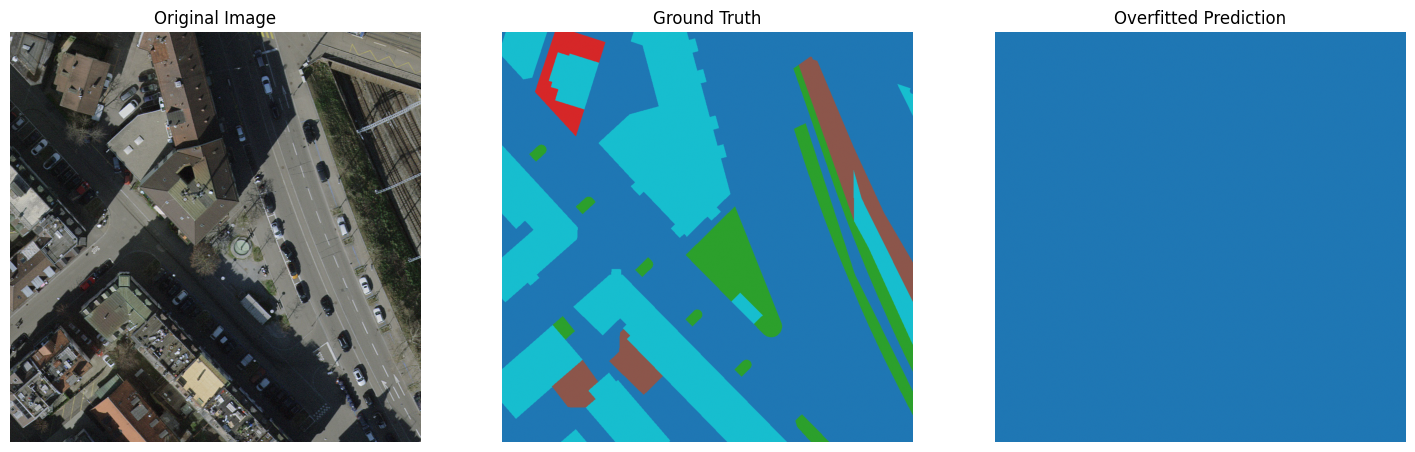

In [11]:
model.eval()
with torch.no_grad():
    images, masks = next(iter(tiny_loader))
    outputs = model(pixel_values=images.to(device))
    logits = F.interpolate(outputs.logits, size=(1024, 1024), mode="bilinear", align_corners=False)
    # Grab the 0th index out of the batch of 4
    predicted_mask = logits.argmax(dim=1)[0].cpu().numpy()

# Format first image for display
img_display = images[0].numpy().transpose(1, 2, 0)
img_display = np.clip(np.array([0.229, 0.224, 0.225]) * img_display + np.array([0.485, 0.456, 0.406]), 0, 1)

fig, axs = plt.subplots(1, 3, figsize=(18, 6))
axs[0].imshow(img_display)
axs[0].set_title("Original Image")
axs[1].imshow(masks[0].numpy(), cmap='tab10', vmin=0, vmax=9)
axs[1].set_title("Ground Truth")
axs[2].imshow(predicted_mask, cmap='tab10', vmin=0, vmax=9)
axs[2].set_title("Overfitted Prediction")
for ax in axs: ax.axis('off')
plt.show()

In [12]:
import pandas as pd

# The dictionary mapping class IDs to human-readable names
id2label = {
    0: 'Impervious / Built-up', 1: 'Forest & Dense Canopy', 2: 'Urban Trees & Bushes',
    3: 'Managed Green Spaces', 4: 'Standard Grassland', 5: 'Ecologically Valuable Meadow',
    6: 'Agriculture & Orchards', 7: 'Water Bodies', 255: 'NoData / Unmapped'
}

# Grab the ground truth and prediction for the displayed image
gt_mask = masks[0].cpu().numpy()
pred_mask = predicted_mask 

# Calculate unique classes and their pixel counts
gt_classes, gt_counts = np.unique(gt_mask, return_counts=True)
pred_classes, pred_counts = np.unique(pred_mask, return_counts=True)

print("📊 GROUND TRUTH (Actual Biotopes):")
print("-" * 50)
for cls, count in zip(gt_classes, gt_counts):
    percentage = (count / (1024 * 1024)) * 100
    print(f"Class {cls:<3} | {id2label.get(cls, 'Unknown'):<28} | {count:>7,d} pixels ({percentage:>5.2f}%)")

print("\n🤖 MODEL PREDICTION:")
print("-" * 50)
for cls, count in zip(pred_classes, pred_counts):
    percentage = (count / (1024 * 1024)) * 100
    print(f"Class {cls:<3} | {id2label.get(cls, 'Unknown'):<28} | {count:>7,d} pixels ({percentage:>5.2f}%)")

📊 GROUND TRUTH (Actual Biotopes):
--------------------------------------------------
Class 0   | Impervious / Built-up        | 636,425 pixels (60.69%)
Class 2   | Urban Trees & Bushes         |  77,194 pixels ( 7.36%)
Class 3   | Managed Green Spaces         |  15,049 pixels ( 1.44%)
Class 5   | Ecologically Valuable Meadow |  47,727 pixels ( 4.55%)
Class 255 | NoData / Unmapped            | 272,181 pixels (25.96%)

🤖 MODEL PREDICTION:
--------------------------------------------------
Class 0   | Impervious / Built-up        | 1,048,576 pixels (100.00%)
